Name : Vishesh Kumar 
Cu24250050    sec: B , rollno : 69  
Experiment-3  , Labsheet -3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
df = pd.read_csv("/workspaces/-Mastery_in_Data-Analytics_and_Visualizations_and_Career-Advancement/WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (1470, 10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

stats_summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Variance": df[numeric_cols].var(),
    "Standard Deviation": df[numeric_cols].std()
})

stats_summary

,Mean,Median,Mode,Variance,Standard Deviation
Age,36.923810,36.0,35.0,83.455049,9.135373
DailyRate,802.485714,802.0,691.0,162819.593737,403.509100
DistanceFromHome,9.192517,7.0,2.0,65.721251,8.106864
Education,2.912925,3.0,3.0,1.048914,1.024165
EmployeeCount,1.000000,1.0,1.0,0.000000,0.000000
EmployeeNumber,1024.865306,1020.5,1.0,362433.299749,602.024335


In [20]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1470 non-null   int64
 1   Attrition         1470 non-null   str  
 2   BusinessTravel    1470 non-null   str  
 3   DailyRate         1470 non-null   int64
 4   Department        1470 non-null   str  
 5   DistanceFromHome  1470 non-null   int64
 6   Education         1470 non-null   int64
 7   EducationField    1470 non-null   str  
 8   EmployeeCount     1470 non-null   int64
 9   EmployeeNumber    1470 non-null   int64
dtypes: int64(6), str(4)
memory usage: 115.0 KB

Missing Values:
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64


In [17]:
# Null Hypothesis (H0)
print("H0: There is no significant difference in Age")
print("between employees who left the company and those who stayed.")

# Alternative Hypothesis (H1)
print("\nH1: There is a significant difference in Age")
print("between employees who left the company and those who stayed.")

H0: There is no significant difference in Age
between employees who left the company and those who stayed.

H1: There is a significant difference in Age
between employees who left the company and those who stayed.


In [15]:
income_left = df[df["Attrition"] == "Yes"]["Age"]

income_stayed = df[df["Attrition"] == "No"]["Age"]

t_stat, p_value = stats.ttest_ind(
    income_left,
    income_stayed,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -5.82801185398895
p-value: 1.3797600649439802e-08


In [18]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a significant difference in Age between employees who left and stayed.")
else:
    print("Fail to Reject H0")
    print("There is no significant difference in Age between employees who left and stayed.")

Reject H0
There is a significant difference in Age between employees who left and stayed.


Pearson Correlation Matrix:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000


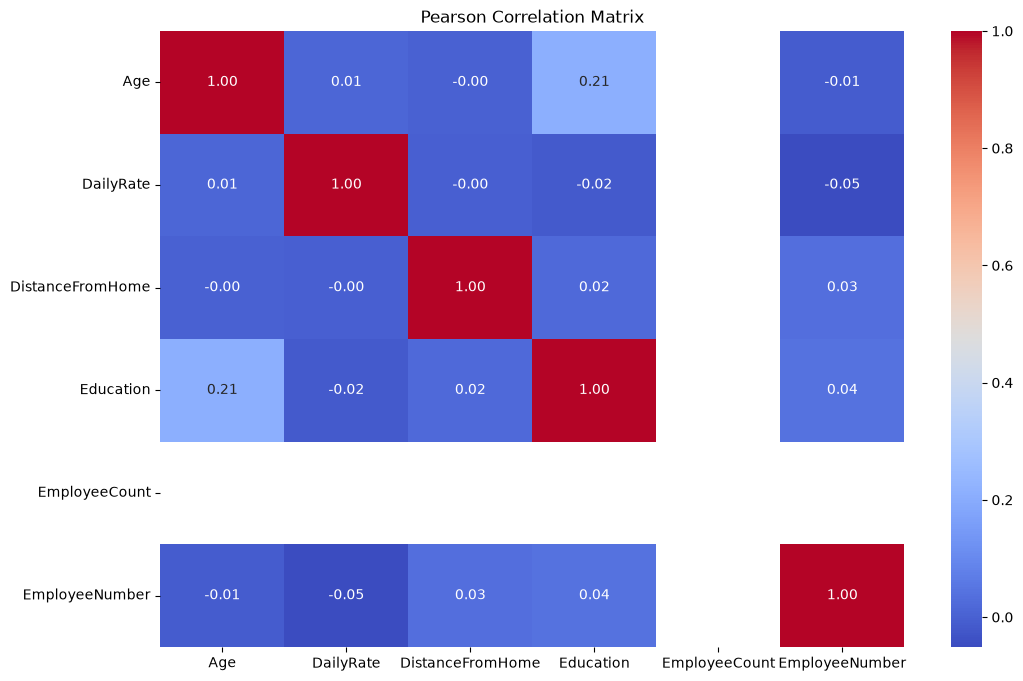

In [19]:
correlation_matrix = df[numeric_cols].corr(method="pearson")

print("Pearson Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Pearson Correlation Matrix")
plt.show()

In [22]:
# Create groups based on Department

groups = [
    group["Age"].values
    for name, group in df.groupby("Department")
]

# Perform One-Way ANOVA
f_stat, anova_p = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", anova_p)

F-statistic: 0.7655031924976905
p-value: 0.46528552999352984


In [23]:
alpha = 0.05

if anova_p < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in Age among Departments.")
else:
    print("Fail to Reject H0")
    print("There is no statistically significant difference in Age among Departments.")

Fail to Reject H0
There is no statistically significant difference in Age among Departments.


In [24]:
X = df[["Age"]]
y = df["DailyRate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R² Score:", r2)
print("RMSE:", rmse)

Intercept: 779.1752549379239
Coefficient: 0.5502555135154229
R² Score: -0.001586107178279228
RMSE: 394.592743838527


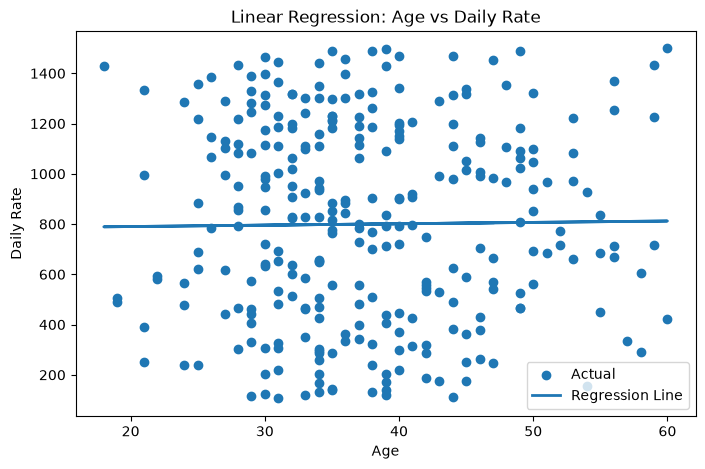

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, linewidth=2, label="Regression Line")

plt.xlabel("Age")
plt.ylabel("Daily Rate")
plt.title("Linear Regression: Age vs Daily Rate")
plt.legend()
plt.show()